In [17]:
import numpy as np 
import matplotlib.pyplot as plt
from numpy.linalg import slogdet
from numpy import sign

### Module 1 main func

In [ ]:
# Module 1 Coding Task : Interatomic Interactions
"""
Calculates reduced potential energy and force magnitude for a pair
of atoms .
TASK : Use the equations to implement the Lennard - Jones potential and
force .
REQUIREMENTS :
1. Implement the shifted potential : phi (r) - phi (rc).
2. Return the force magnitude divided by r ( force /r).
"""
def calculate_lj_properties(r_sq, r_cutoff_sq):
    inv_rc2 = 1.0 / r_cutoff_sq
    inv_rc6 = inv_rc2**3
    inv_rc12 = inv_rc6**2
    phi_cut = 4 * (inv_rc12 - inv_rc6)
    
    inv_r2 = 1.0 / r_sq
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2
    
    phi = 4 * (inv_r12 - inv_r6)
    

    potE = phi - phi_cut
    
    force_by_r = 48 * inv_r2 * (inv_r12 - 0.5 * inv_r6)

    return potE, force_by_r



### Cutoff plots

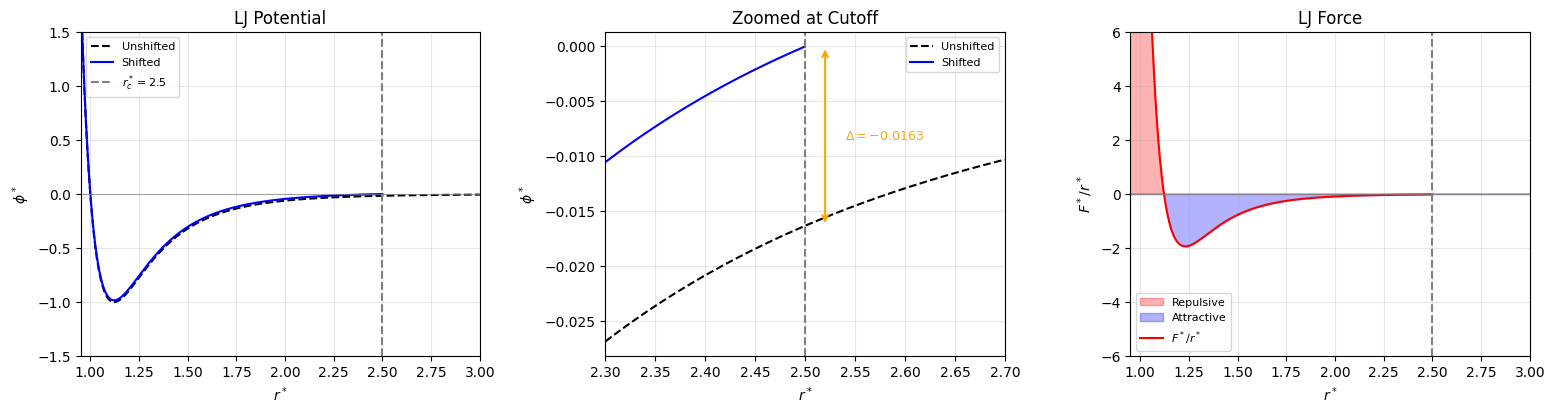

In [19]:
rc = 2.5
r  = np.linspace(0.95, 3.0, 2000)

def phi(r): return 4*(r**-12 - r**-6)
def fdr(r): return 48*r**-2*(r**-12 - 0.5*r**-6)

inside = r < rc
pu = phi(r)
ps = np.where(inside, pu - phi(rc), np.nan)
f  = np.where(inside, fdr(r), np.nan)

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16, 4.5))

a1.plot(r, pu, 'k--', label='Unshifted')
a1.plot(r, ps, 'b-',  label='Shifted')
a1.axvline(rc, color='gray', ls='--', label=r'$r_c^*=2.5$')
a1.axhline(0,  color='gray', lw=0.5)
a1.set(xlim=(0.95, 3), ylim=(-1.5, 1.5),
       xlabel=r'$r^*$', ylabel=r'$\phi^*$', title='LJ Potential')
a1.legend(fontsize=8); a1.grid(alpha=0.3)

r_z  = np.linspace(2.3, 2.7, 500)
pu_z = phi(r_z)
ps_z = np.where(r_z < rc, pu_z - phi(rc), np.nan)
a2.plot(r_z, pu_z, 'k--', label='Unshifted')
a2.plot(r_z, ps_z, 'b-',  label='Shifted')
a2.axvline(rc, color='gray', ls='--')
a2.annotate("", xy=(rc+0.02, 0), xytext=(rc+0.02, phi(rc)),
            arrowprops=dict(arrowstyle='<->', color='orange', lw=1.5))
a2.text(rc+0.04, phi(rc)/2, fr'$\Delta={phi(rc):.4f}$',
        color='orange', fontsize=9, va='center')
a2.set(xlim=(2.3, 2.7), xlabel=r'$r^*$', ylabel=r'$\phi^*$', title='Zoomed at Cutoff')
a2.legend(fontsize=8); a2.grid(alpha=0.3)

a3.fill_between(r, 0, np.where(f > 0, f, 0), alpha=0.3, color='red',  label='Repulsive')
a3.fill_between(r, 0, np.where(f < 0, f, 0), alpha=0.3, color='blue', label='Attractive')
a3.plot(r, f, 'r-', lw=1.5, label=r'$F^*/r^*$')
a3.axvline(rc, color='gray', ls='--')
a3.axhline(0,  color='gray', lw=0.5)
a3.set(xlim=(0.95, 3), ylim=(-6, 6),
       xlabel=r'$r^*$', ylabel=r'$F^*/r^*$', title='LJ Force')
a3.legend(fontsize=8); a3.grid(alpha=0.3)

plt.tight_layout(pad=2.0)
plt.subplots_adjust(left=0.07)
plt.savefig('m1_lj_curves.pdf', dpi=150)
plt.show()

In [20]:
r_cutoff    = 2.5
r_cutoff_sq = r_cutoff ** 2

def phi_lj(r_sq):
    i2 = 1.0 / r_sq; i6 = i2**3
    return 4 * (i6**2 - i6)

print(f"Module 1 Verification Tests (r_c* = {r_cutoff})")
print("=" * 50)

# r* = 1.0 : zero crossing, repulsive
p1, f1 = calculate_lj_properties(1.0, r_cutoff_sq)
print(f"\nr* = 1.0  (zero-point)")
print(f"  phi_unshifted = {phi_lj(1.0):.6f}   expected 0.0")
print(f"  force/r       = {f1:.4f}          expected > 0")

# r* = 2^(1/6) : potential minimum
r_min = 2 ** (1/6)
p2, f2 = calculate_lj_properties(r_min**2, r_cutoff_sq)
print(f"\nr* = 2^(1/6) = {r_min:.4f}  (minimum)")
print(f"  phi_unshifted = {phi_lj(r_min**2):.6f}   expected -1.0")
print(f"  force/r       = {f2:.2e}       expected ~ 0")

# r* = 2.5 : cutoff, shifted phi must vanish
p3, f3 = calculate_lj_properties(r_cutoff_sq, r_cutoff_sq)
print(f"\nr* = r_c* = {r_cutoff}  (cutoff)")
print(f"  phi_shifted   = {p3:.6f}   expected 0.0")
print(f"  force/r       = {f3:.4f}          expected non-zero")

Module 1 Verification Tests (r_c* = 2.5)

r* = 1.0  (zero-point)
  phi_unshifted = 0.000000   expected 0.0
  force/r       = 24.0000          expected > 0

r* = 2^(1/6) = 1.1225  (minimum)
  phi_unshifted = -1.000000   expected -1.0
  force/r       = -2.11e-15       expected ~ 0

r* = r_c* = 2.5  (cutoff)
  phi_shifted   = 0.000000   expected 0.0
  force/r       = -0.0156          expected non-zero
